In [1]:
import os
import time
import numpy as np
import pandas as pd

import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
    average_precision_score
)
import matplotlib.pyplot as plt




base = r"C:\Users\makis\ember_data\win64_clean"

dim = 2568
Random_State = 13


# LOAD 
X_train = np.memmap(os.path.join(base, "X_train.dat"), dtype=np.float32, mode="r").reshape(-1, dim)
y_train = np.memmap(os.path.join(base, "y_train.dat"), dtype=np.int32, mode="r")

X_test  = np.memmap(os.path.join(base, "X_test.dat"),  dtype=np.float32, mode="r").reshape(-1, dim)
y_test  = np.memmap(os.path.join(base, "y_test.dat"),  dtype=np.int32, mode="r")

print(
    "Train rows:", X_train.shape[0],
    ", Train features:", X_train.shape[1],
    ", Test rows:", X_test.shape[0],
    ", Test features:", X_test.shape[1]
)
print("Train label counts:", dict(pd.Series(y_train).value_counts()))
print("Test  label counts:", dict(pd.Series(y_test).value_counts()))





Train rows: 520000 , Train features: 2568 , Test rows: 120000 , Test features: 2568
Train label counts: {0: 260000, 1: 260000}
Test  label counts: {0: 60000, 1: 60000}



Training baseline LightGBM...


C:\Users\makis\anaconda3\envs\ember2024\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training time: 509.28 seconds

=== LIGHTGBM BASELINE (TEST SET) ===
Accuracy  : 0.987108
Precision : 0.989646
Recall    : 0.984517
F1 score  : 0.987075
Log loss  : 0.037884
ROC AUC   : 0.998912
PR AUC    : 0.999025

Confusion Matrix [[TN FP],[FN TP]]:
[[59382   618]
 [  929 59071]]


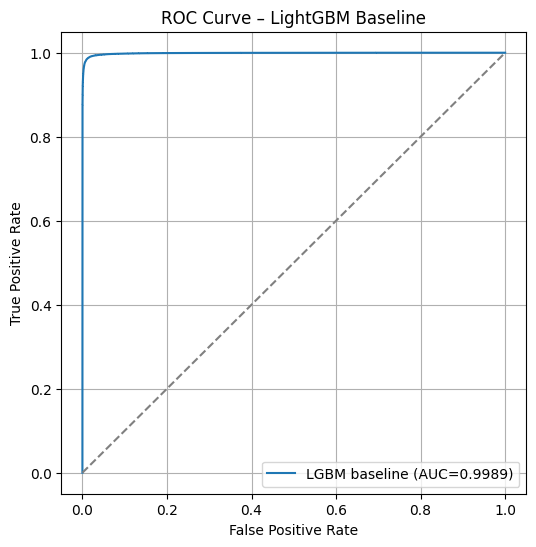

In [2]:
# LIGHTGBM BASELINE (paper)
# Paper hyperparams:
# - 500 boosting rounds
# - 64 leaves
# - 100 min data in leaf

lgbm = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,      
    num_leaves=64,         
    min_child_samples=100, 
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)


categorical_feature = [2, 3, 4, 5, 6, 701, 702]

print("\nTraining baseline LightGBM...")
start_time = time.perf_counter()
lgbm.fit(
    X_train, y_train,
    categorical_feature=categorical_feature
)
end_time = time.perf_counter()
train_time = end_time - start_time



# PREDICT (TEST)

y_test_proba = lgbm.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)



# METRICS

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)



# OUTPUT

print(f"Training time: {train_time:.2f} seconds")
print("\n=== LIGHTGBM BASELINE (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)



# OPTIONAL ROC PLOT

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM baseline (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Baseline")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names*"
)

In [5]:
SUBSET_SIZE = 150_000   
TRAIN_SIZE  = 140_000
TEST_SIZE   = 10_000


X_full = X_train
y_full = y_train

X_sub = X_full[:SUBSET_SIZE]
y_sub = y_full[:SUBSET_SIZE]


X_tr = X_sub[:TRAIN_SIZE]
y_tr = y_sub[:TRAIN_SIZE]

X_val = X_sub[TRAIN_SIZE:TRAIN_SIZE + TEST_SIZE]
y_val = y_sub[TRAIN_SIZE:TRAIN_SIZE + TEST_SIZE]


# shuffle TRAIN
rng_tr = np.random.RandomState(42)
perm_tr = rng_tr.permutation(len(X_tr))
X_tr = X_tr[perm_tr]
y_tr = y_tr[perm_tr]

# shuffle VAL 
rng_val = np.random.RandomState(43)
perm_val = rng_val.permutation(len(X_val))
X_val = X_val[perm_val]
y_val = y_val[perm_val]

# sanity check
print("Train size:", X_tr.shape, "labels:", dict(pd.Series(y_tr).value_counts()))
print("Val   size:", X_val.shape, "labels:", dict(pd.Series(y_val).value_counts()))

Train size: (140000, 2568) labels: {0: 70000, 1: 70000}
Val   size: (10000, 2568) labels: {0: 5000, 1: 5000}


In [6]:
#tuning
from lightgbm import LGBMClassifier, early_stopping

N_ESTIMATORS = 3000
EARLY_STOPPING_ROUNDS = 50


lr_list         = [0.03, 0.05, 0.075]
num_leaves_list = [ 63, 127, 255]
min_child_list  = [ 100, 200, 300]
  

results = []
run_id = 0

for lr in lr_list:
    for num_leaves in num_leaves_list:
        for min_child in min_child_list:

                            run_id += 1
                            params = {
                                "learning_rate": lr,
                                "num_leaves": num_leaves,
                                "min_child_samples": min_child,
                                
                            }

                            print(f"\nRun #{run_id} | {params}")

                            model = LGBMClassifier(
                                objective="binary",
                                n_estimators=N_ESTIMATORS,
                                n_jobs=-1,
                                random_state=42,
                                **params
                            )

                            start = time.time()
                            model.fit(
                                X_tr, y_tr,
                                eval_set=[(X_val, y_val)],
                                eval_metric="binary_logloss",  
                                callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
                            )
                            train_time = time.time() - start

                            # Predict
                            p_val = model.predict_proba(X_val)[:, 1]
                            y_hat = (p_val >= 0.5).astype(int)

                            # Metrics
                            acc  = accuracy_score(y_val, y_hat)
                            prec = precision_score(y_val, y_hat, zero_division=0)
                            rec  = recall_score(y_val, y_hat, zero_division=0)
                            f1   = f1_score(y_val, y_hat, zero_division=0)

                            ll   = log_loss(y_val, p_val)
                            roc  = roc_auc_score(y_val, p_val)
                            pr   = average_precision_score(y_val, p_val)

                            cm = confusion_matrix(y_val, y_hat)
                            tn, fp, fn, tp = cm.ravel()

                            row = {
                                "run_id": run_id,
                                "train_time_sec": train_time,
                                "best_iteration": getattr(model, "best_iteration_", None),

                                
                                **params,

                                
                                "accuracy": acc,
                                "precision": prec,
                                "recall": rec,
                                "f1": f1,
                                "logloss": ll,
                                "roc_auc": roc,
                                "pr_auc": pr,

                                
                                "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
                            }

                            results.append(row)

                            print(
                                f"AUC={roc:.6f} | PR-AUC={pr:.6f} | LogLoss={ll:.6f} | "
                                f"Acc={acc:.6f} | F1={f1:.6f} | "
                                f"TN={tn} FP={fp} FN={fn} TP={tp} | "
                                f"best_iter={row['best_iteration']} | time={train_time:.1f}s"
                            )


df = pd.DataFrame(results)


df_sorted = df.sort_values(["roc_auc","pr_auc"], ascending=False)

print("\n====================")
print("TOP 10 (sorted by ROC-AUC then PR-AUC)")
print(df_sorted.head(10)[[
    "pr_auc", "roc_auc", "logloss", "accuracy", "f1",
    "best_iteration", "train_time_sec",
    "learning_rate", "num_leaves", "min_child_samples",
    "tn", "fp", "fn", "tp"
]])

# Save results
out_csv = "lgbm_manual_grid_results_win64.csv"
df_sorted.to_csv(out_csv, index=False)
print(f"\nSaved all results to: {out_csv}")


Run #1 | {'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 100}
AUC=0.999192 | PR-AUC=0.999248 | LogLoss=0.032841 | Acc=0.988400 | F1=0.988419 | TN=4934 FP=66 FN=50 TP=4950 | best_iter=892 | time=412.3s

Run #2 | {'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 200}
AUC=0.999163 | PR-AUC=0.999229 | LogLoss=0.032782 | Acc=0.988800 | F1=0.988811 | TN=4939 FP=61 FN=51 TP=4949 | best_iter=861 | time=402.7s

Run #3 | {'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 300}
AUC=0.999153 | PR-AUC=0.999229 | LogLoss=0.032612 | Acc=0.988100 | F1=0.988118 | TN=4933 FP=67 FN=52 TP=4948 | best_iter=771 | time=373.5s

Run #4 | {'learning_rate': 0.03, 'num_leaves': 127, 'min_child_samples': 100}
AUC=0.999094 | PR-AUC=0.999167 | LogLoss=0.034413 | Acc=0.988700 | F1=0.988710 | TN=4939 FP=61 FN=52 TP=4948 | best_iter=479 | time=367.4s

Run #5 | {'learning_rate': 0.03, 'num_leaves': 127, 'min_child_samples': 200}
AUC=0.999105 | PR-AUC=0.999175 | LogLoss=0.034330 | 

In [7]:
#tuning
from lightgbm import LGBMClassifier, early_stopping

N_ESTIMATORS = 3000
EARLY_STOPPING_ROUNDS = 50

FIXED_LEARNING_RATE = 0.03
FIXED_NUM_LEAVES = 63
FIXED_MIN_CHILD_SAMPLES = 100


feature_fraction_list   = [0.70, 0.85, 1.00]
bagging_fraction_list   = [0.70, 0.85, 1.00]
min_split_gain_list     = [0.00, 0.05, 0.10]

results = []
run_id = 0

for ff in feature_fraction_list:
    for bf in bagging_fraction_list:
        for msg in min_split_gain_list:

            run_id += 1
            tune_params = {
                "feature_fraction": ff,
                "bagging_fraction": bf,
                "bagging_freq": 1,          
                "min_split_gain": msg,
            }

            print(f"\nRun #{run_id} | {tune_params}")

            model = LGBMClassifier(
                objective="binary",
                n_estimators=N_ESTIMATORS,
                n_jobs=-1,
                random_state=42,
                # fixed core params
                learning_rate=FIXED_LEARNING_RATE,
                num_leaves=FIXED_NUM_LEAVES,
                min_child_samples=FIXED_MIN_CHILD_SAMPLES,
                # tuned params
                **tune_params
            )

            start = time.time()
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                eval_metric="auc",  
                callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
            )
            train_time = time.time() - start

            # Predict
            p_val = model.predict_proba(X_val)[:, 1]
            y_hat = (p_val >= 0.5).astype(int)

            # Metrics
            acc  = accuracy_score(y_val, y_hat)
            prec = precision_score(y_val, y_hat, zero_division=0)
            rec  = recall_score(y_val, y_hat, zero_division=0)
            f1   = f1_score(y_val, y_hat, zero_division=0)

            ll   = log_loss(y_val, p_val)
            roc  = roc_auc_score(y_val, p_val)
            pr   = average_precision_score(y_val, p_val)

            cm = confusion_matrix(y_val, y_hat)
            tn, fp, fn, tp = cm.ravel()

            row = {
                "run_id": run_id,
                "train_time_sec": train_time,
                "best_iteration": getattr(model, "best_iteration_", None),

                # fixed core params
                "learning_rate": FIXED_LEARNING_RATE,
                "num_leaves": FIXED_NUM_LEAVES,
                "min_child_samples": FIXED_MIN_CHILD_SAMPLES,

                # tuned params 
                **tune_params,

                # metrics
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1,
                "logloss": ll,
                "roc_auc": roc,
                "pr_auc": pr,

                # confusion matrix
                "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            }

            results.append(row)

            print(
                f"AUC={roc:.6f} | PR-AUC={pr:.6f} | LogLoss={ll:.6f} | "
                f"Acc={acc:.6f} | F1={f1:.6f} | "
                f"TN={tn} FP={fp} FN={fn} TP={tp} | "
                f"best_iter={row['best_iteration']} | time={train_time:.1f}s"
            )

df = pd.DataFrame(results)

# Sort by ROC-AUC first
df_sorted = df.sort_values(["roc_auc", "pr_auc"], ascending=False)

print("\n====================")
print("TOP 10 (sorted by ROC-AUC then PR-AUC)")
print(df_sorted.head(10)[[
    "roc_auc", "pr_auc", "logloss", "accuracy", "f1",
    "best_iteration", "train_time_sec",
    "learning_rate", "num_leaves", "min_child_samples",
    "feature_fraction", "bagging_fraction", "bagging_freq", "min_split_gain",
    "tn", "fp", "fn", "tp"
]])

# Save results
out_csv = "lgbm_auc_grid_results_win64.csv"
df_sorted.to_csv(out_csv, index=False)
print(f"\nSaved all results to: {out_csv}")


Run #1 | {'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'min_split_gain': 0.0}
AUC=0.999140 | PR-AUC=0.999218 | LogLoss=0.032724 | Acc=0.989200 | F1=0.989206 | TN=4943 FP=57 FN=51 TP=4949 | best_iter=914 | time=349.6s

Run #2 | {'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'min_split_gain': 0.05}
AUC=0.999117 | PR-AUC=0.999198 | LogLoss=0.032994 | Acc=0.988700 | F1=0.988712 | TN=4938 FP=62 FN=51 TP=4949 | best_iter=871 | time=320.3s

Run #3 | {'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'min_split_gain': 0.1}
AUC=0.999131 | PR-AUC=0.999209 | LogLoss=0.032914 | Acc=0.988800 | F1=0.988807 | TN=4941 FP=59 FN=53 TP=4947 | best_iter=898 | time=325.4s

Run #4 | {'feature_fraction': 0.7, 'bagging_fraction': 0.85, 'bagging_freq': 1, 'min_split_gain': 0.0}
AUC=0.999141 | PR-AUC=0.999213 | LogLoss=0.032969 | Acc=0.987800 | F1=0.987817 | TN=4932 FP=68 FN=54 TP=4946 | best_iter=745 | time=293.9s

Run #5 | {'feature_fraction':


Training tuned LightGBM...
Training time: 1329.23 seconds

=== LIGHTGBM tuned (TEST SET) ===
Accuracy  : 0.987408
Precision : 0.989325
Recall    : 0.985450
F1 score  : 0.987384
Log loss  : 0.037143
ROC AUC   : 0.998933
PR AUC    : 0.999045

Confusion Matrix [[TN FP],[FN TP]]:
[[59362   638]
 [  873 59127]]


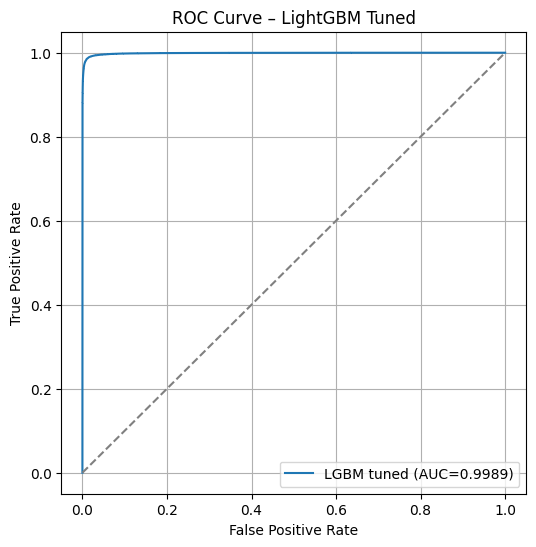

In [11]:
lgbm_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    num_leaves=64,
    min_child_samples=100,
    learning_rate=0.03,
    feature_fraction=1,
    bagging_freq = 1,
    bagging_fraction=1,
    min_split_gain=0.1,
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)

categorical_feature = [2, 3, 4, 5, 6, 701, 702]

print("\nTraining tuned LightGBM...")
start_time = time.perf_counter()
lgbm_final.fit(
    X_train, y_train,
    categorical_feature=categorical_feature
)
end_time = time.perf_counter()
train_time = end_time - start_time



# PREDICT (TEST)

y_test_proba = lgbm_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)



# METRICS

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)



# OUTPUT

print(f"Training time: {train_time:.2f} seconds")
print("\n=== LIGHTGBM tuned (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)



# OPTIONAL ROC PLOT

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM tuned (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Tuned")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Paths / settings

base = r"C:\Users\makis\ember_data\win64_clean"
FULL_DIM = 2568
RANDOM_STATE = 13


# Load full memmaps

X_train_full = np.memmap(os.path.join(base, "X_train.dat"), dtype=np.float32, mode="r").reshape(-1, dim)
y_train = np.memmap(os.path.join(base, "y_train.dat"), dtype=np.int32, mode="r")

X_test_full  = np.memmap(os.path.join(base, "X_test.dat"),  dtype=np.float32, mode="r").reshape(-1, dim)
y_test  = np.memmap(os.path.join(base, "y_test.dat"),  dtype=np.int32, mode="r")

print(
    "Train rows:", X_train_full.shape[0],
    ", Train features:", X_train_full.shape[1],
    ", Test rows:", X_test_full.shape[0],
    ", Test features:", X_test_full.shape[1]
)
print("Train label counts:", dict(pd.Series(y_train).value_counts()))
print("Test  label counts:", dict(pd.Series(y_test).value_counts()))

Train rows: 520000 , Train features: 2568 , Test rows: 120000 , Test features: 2568
Train label counts: {0: 260000, 1: 260000}
Test  label counts: {0: 60000, 1: 60000}



Using only ByteHistogram + ByteEntropyHistogram features: cols [7:519)
New Train shape: (520000, 512) New Test shape: (120000, 512)

 Training final model on train

Final training time (FULL train): 729.06 seconds

=== LIGHTGBM FINAL (TEST SET) ===
Accuracy  : 0.965250
Precision : 0.974100
Recall    : 0.955917
F1 score  : 0.964923
Log loss  : 0.097803
ROC AUC   : 0.994153
PR AUC    : 0.994480

Confusion Matrix [[TN FP],[FN TP]]:
[[58475  1525]
 [ 2645 57355]]


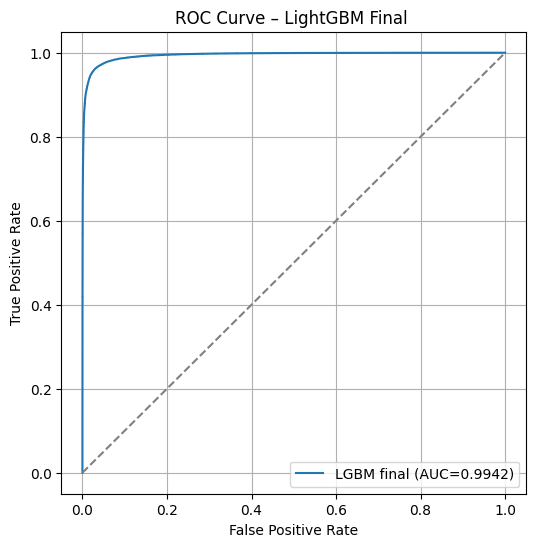

In [15]:
# Feature slicing(histogram + byteentropy)

GENERAL_DIM = 7
HIST_DIM = 256
ENT_DIM = 256

start = GENERAL_DIM
end = GENERAL_DIM + HIST_DIM + ENT_DIM  

X_train = X_train_full[:, start:end]
X_test = X_test_full[:, start:end]

print(f"\nUsing only ByteHistogram + ByteEntropyHistogram features: cols [{start}:{end})")
print("New Train shape:", X_train.shape, "New Test shape:", X_test.shape)



lgbm_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    num_leaves=64,
    min_child_samples=100,
    learning_rate=0.03,
    feature_fraction=1,
    bagging_freq = 1,
    bagging_fraction=1,
    min_split_gain=0.1,
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)

print("\n Training final model on train")
start_time = time.perf_counter()
lgbm_final.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# PREDICT (TEST)
y_test_proba = lgbm_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# METRICS
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

# OUTPUT
print(f"\nFinal training time (FULL train): {train_time:.2f} seconds")
print("\n=== LIGHTGBM FINAL (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# ROC PLOT
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM final (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Final ")
plt.legend()
plt.grid(True)
plt.show()


Using ONLY IMPORT features: cols [994:2276)
New Train shape: (520000, 1282)
New Test shape : (120000, 1282)

 Training final model on train

Final training time (FULL train): 97.75 seconds

=== LIGHTGBM FINAL (TEST SET) ===
Accuracy  : 0.934275
Precision : 0.914049
Recall    : 0.958700
F1 score  : 0.935842
Log loss  : 0.167498
ROC AUC   : 0.983002
PR AUC    : 0.979637

Confusion Matrix [[TN FP],[FN TP]]:
[[54591  5409]
 [ 2478 57522]]


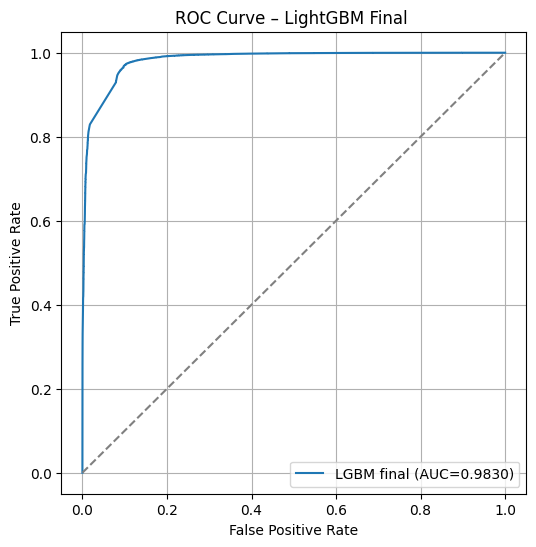

In [16]:
# IMPORT FEATURES ONLY

# General(7) + ByteHist(256) + ByteEntropy(256) + Strings(177) + HeaderFileInfo(74) + SectionInfo(224) 
IMPORT_START = 7 + 256 + 256 + 177 + 74 + 224
IMPORT_DIM = 1282
IMPORT_END = IMPORT_START + IMPORT_DIM

X_train = X_train_full[:, IMPORT_START:IMPORT_END]
X_test  = X_test_full[:, IMPORT_START:IMPORT_END]

print(f"\nUsing ONLY IMPORT features: cols [{IMPORT_START}:{IMPORT_END})")
print("New Train shape:", X_train.shape)
print("New Test shape :", X_test.shape)

lgbm_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    num_leaves=64,
    min_child_samples=100,
    learning_rate=0.03,
    feature_fraction=1,
    bagging_freq = 1,
    bagging_fraction=1,
    min_split_gain=0.1,
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)

print("\n Training final model on train")
start_time = time.perf_counter()
lgbm_final.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# PREDICT (TEST)
y_test_proba = lgbm_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# METRICS
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

# OUTPUT
print(f"\nFinal training time (FULL train): {train_time:.2f} seconds")
print("\n=== LIGHTGBM FINAL (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# ROC PLOT
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM final (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Final ")
plt.legend()
plt.grid(True)
plt.show()


Using ONLY EXPORT features: cols [2276:2405)
New Train shape: (520000, 129)
New Test shape : (120000, 129)

 Training final model on train

Final training time (FULL train): 30.10 seconds

=== LIGHTGBM FINAL (TEST SET) ===
Accuracy  : 0.851008
Precision : 0.789376
Recall    : 0.957500
F1 score  : 0.865348
Log loss  : 0.380594
ROC AUC   : 0.863075
PR AUC    : 0.790453

Confusion Matrix [[TN FP],[FN TP]]:
[[44671 15329]
 [ 2550 57450]]


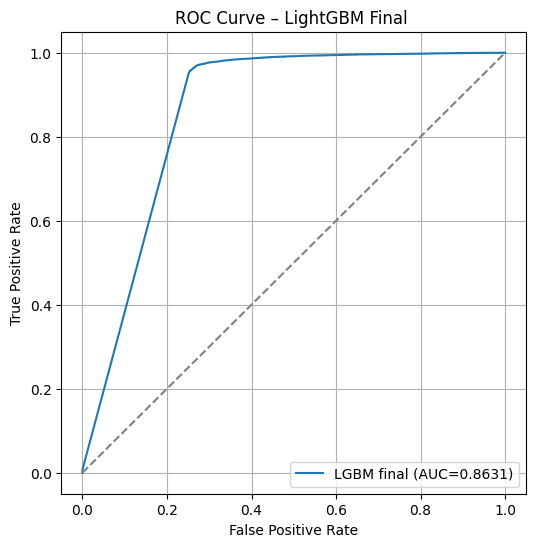

In [17]:
# EXPORT FEATURES ONLY

EXPORT_START = 7 + 256 + 256 + 177 + 74 + 224 + 1282
EXPORT_END   = EXPORT_START + 129

X_train = X_train_full[:, EXPORT_START:EXPORT_END]
X_test  = X_test_full[:,  EXPORT_START:EXPORT_END]

print(f"\nUsing ONLY EXPORT features: cols [{EXPORT_START}:{EXPORT_END})")
print("New Train shape:", X_train.shape)
print("New Test shape :", X_test.shape)

lgbm_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    num_leaves=64,
    min_child_samples=100,
    learning_rate=0.03,
    feature_fraction=1,
    bagging_freq = 1,
    bagging_fraction=1,
    min_split_gain=0.1,
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)

print("\n Training final model on train")
start_time = time.perf_counter()
lgbm_final.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# PREDICT (TEST)
y_test_proba = lgbm_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# METRICS
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

# OUTPUT
print(f"\nFinal training time (FULL train): {train_time:.2f} seconds")
print("\n=== LIGHTGBM FINAL (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# ROC PLOT
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM final (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Final ")
plt.legend()
plt.grid(True)
plt.show()


Using ONLY Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning features: cols [2405:2568)
New Train shape: (520000, 163)
New Test shape : (120000, 163)

 Training final model on train

Final training time (FULL train): 40.99 seconds

=== LIGHTGBM FINAL (TEST SET) ===
Accuracy  : 0.973625
Precision : 0.977886
Recall    : 0.969167
F1 score  : 0.973507
Log loss  : 0.071512
ROC AUC   : 0.996580
PR AUC    : 0.996842

Confusion Matrix [[TN FP],[FN TP]]:
[[58685  1315]
 [ 1850 58150]]


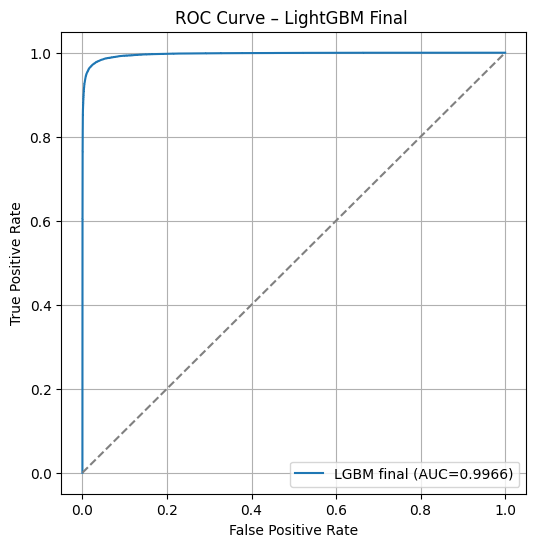

In [18]:
# Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning

EXPORT_START = 7 + 256 + 256 + 177 + 74 + 224 + 1282 + 129
EXPORT_END   = EXPORT_START + 34 + 33 + 8 + 88

X_train = X_train_full[:, EXPORT_START:EXPORT_END]
X_test  = X_test_full[:,  EXPORT_START:EXPORT_END]

print(f"\nUsing ONLY Data Directories, Rich Header, AuthenticationSignature, PEFormatWarning features: cols [{EXPORT_START}:{EXPORT_END})")
print("New Train shape:", X_train.shape)
print("New Test shape :", X_test.shape)

lgbm_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    num_leaves=64,
    min_child_samples=100,
    learning_rate=0.03,
    feature_fraction=1,
    bagging_freq = 1,
    bagging_fraction=1,
    min_split_gain=0.1,
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)

print("\n Training final model on train")
start_time = time.perf_counter()
lgbm_final.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# PREDICT (TEST)
y_test_proba = lgbm_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# METRICS
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

# OUTPUT
print(f"\nFinal training time (FULL train): {train_time:.2f} seconds")
print("\n=== LIGHTGBM FINAL (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# ROC PLOT
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM final (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Final ")
plt.legend()
plt.grid(True)
plt.show()

Using General + Strings + Header + Section
Train shape: (520000, 482)
Test shape : (120000, 482)

 Training final model on train

Final training time (FULL train): 319.90 seconds

=== LIGHTGBM FINAL (TEST SET) ===
Accuracy  : 0.984242
Precision : 0.987026
Recall    : 0.981383
F1 score  : 0.984196
Log loss  : 0.044689
ROC AUC   : 0.998510
PR AUC    : 0.998668

Confusion Matrix [[TN FP],[FN TP]]:
[[59226   774]
 [ 1117 58883]]


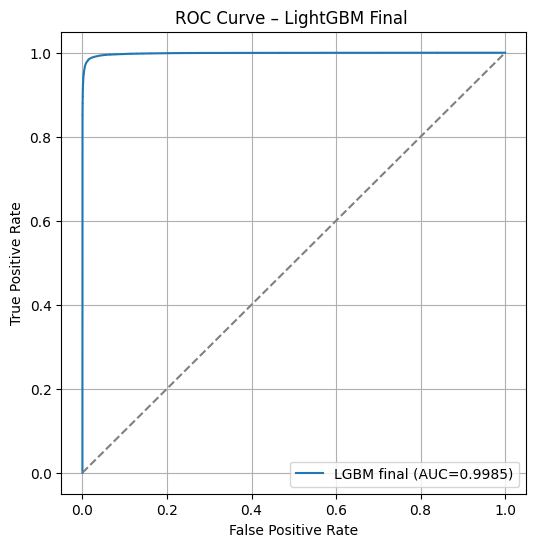

In [19]:
#GeneralFileInfo+ Strings+ HeaderInfo+ SectionInfo
GEN_START, GEN_END = 0, 7
STR_START, SEC_END = 519, 994   # Strings+Header+Section

X_train = np.hstack([ X_train_full[:, GEN_START:GEN_END], X_train_full[:, STR_START:SEC_END]])

X_test = np.hstack([ X_test_full[:, GEN_START:GEN_END], X_test_full[:, STR_START:SEC_END]])

print("Using General + Strings + Header + Section")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
assert X_train.shape[1] == X_test.shape[1]

lgbm_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    num_leaves=64,
    min_child_samples=100,
    learning_rate=0.03,
    feature_fraction=1,
    bagging_freq = 1,
    bagging_fraction=1,
    min_split_gain=0.1,
    n_jobs=-1,
    random_state=Random_State,
    verbose=-1
)

print("\n Training final model on train")
start_time = time.perf_counter()
lgbm_final.fit(X_train, y_train)
train_time = time.perf_counter() - start_time

# PREDICT (TEST)
y_test_proba = lgbm_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# METRICS
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)

ll   = log_loss(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

# OUTPUT
print(f"\nFinal training time (FULL train): {train_time:.2f} seconds")
print("\n=== LIGHTGBM FINAL (TEST SET) ===")
print(f"Accuracy  : {acc:.6f}")
print(f"Precision : {prec:.6f}")
print(f"Recall    : {rec:.6f}")
print(f"F1 score  : {f1:.6f}")
print(f"Log loss  : {ll:.6f}")
print(f"ROC AUC   : {roc_auc:.6f}")
print(f"PR AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)

# ROC PLOT
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LGBM final (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM Final ")
plt.legend()
plt.grid(True)
plt.show()